Portfolio Construction and Tail Risk Diagnostics

In [159]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.optimize as sco

Step 1: Data Preparation

In [160]:
tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS','ITC.NS', 'HINDUNILVR.NS', 'BHARTIARTL.NS', 'LT.NS', 'TMPV.NS']

In [161]:
print("Historical data for 10 assets")

raw_data = yf.download(tickers, start='2021-01-01', end='2026-01-01', group_by='ticker')


data_dict = {}
for ticker in tickers:
    ticker_df = raw_data[ticker]
    if 'Adj Close' in ticker_df.columns:
        data_dict[ticker] = ticker_df['Adj Close']
    else:
        data_dict[ticker] = ticker_df['Close']

data = pd.DataFrame(data_dict).dropna()

Historical data for 10 assets


[*********************100%***********************]  10 of 10 completed


In [162]:
print("From Daily closing prices to daily log returns")

returns = np.log(data / data.shift(1)).dropna()

From Daily closing prices to daily log returns


In [163]:
print("Annualized Log Returns and Covariance Matrix")

n_assets = len(tickers)
annual_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

Annualized Log Returns and Covariance Matrix


In [164]:
print("Annualized Expected Returns:")
print(annual_returns)

Annualized Expected Returns:
RELIANCE.NS      0.113321
TCS.NS           0.041514
HDFCBANK.NS      0.078431
INFY.NS          0.076637
ICICIBANK.NS     0.197478
ITC.NS           0.179137
HINDUNILVR.NS    0.010884
BHARTIARTL.NS    0.295748
LT.NS            0.244717
TMPV.NS          0.141962
dtype: float64


Step 2: Optimization

In [165]:
def port_performance(weights, returns, cov_matrix):
    
    port_return = np.sum(returns.mean() * weights) * 252
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_volatility

print("the above function gives portfolio expected returns and volatility as a function of weights")

the above function gives portfolio expected returns and volatility as a function of weights


In [166]:
def min_var(weights, returns, cov_matrix):
    return port_performance(weights, returns, cov_matrix)[1] ** 2

print("this is the objective function to be minimized")

this is the objective function to be minimized


The below code defines the constraints and bound which are:-
1. Sum of weights=1
2. No Short Selling ( each weight is in between 0 and 1)
3. Initial weight vector, assignes equal weight to all securities.

In [167]:
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}) 
print("portfolio weights sum to 1")

portfolio weights sum to 1


In [168]:
bounds = tuple((0, 1) for i in range(n_assets))
print("Each weight between 0 and 1")

Each weight between 0 and 1


In [169]:
init_weights = num_assets * [1.0 / num_assets]
print("inital weight vector")

inital weight vector


The below code executes the optimization.

In [170]:
optimized_result = sco.minimize(fun=min_var, x0=init_weights, args=(returns, cov_matrix), method='SLSQP', 
                                   bounds=bounds, constraints=constraints)

In [171]:
print("the optimal weights are:")
opt_weights = optimized_result.x
print(opt_weights)

the optimal weights are:
[4.70550899e-02 1.72853450e-01 1.30107028e-01 0.00000000e+00
 7.88954090e-02 1.87843112e-01 2.26001958e-01 1.24787364e-01
 3.24565892e-02 4.27843887e-18]


In [172]:
opt_return, opt_vol = port_performance(opt_weights,returns,cov_matrix)

In [173]:
print('Final Output')
print("\nOptimized Portfolio Weights (Minimum Variance)")
for ticker, weight in zip(tickers, opt_weights):
    print(f"{ticker}: {weight:.2%}")

Final Output

Optimized Portfolio Weights (Minimum Variance)
RELIANCE.NS: 4.71%
TCS.NS: 17.29%
HDFCBANK.NS: 13.01%
INFY.NS: 0.00%
ICICIBANK.NS: 7.89%
ITC.NS: 18.78%
HINDUNILVR.NS: 22.60%
BHARTIARTL.NS: 12.48%
LT.NS: 3.25%
TMPV.NS: 0.00%


Step 3: Risk Tracking and Measurement

In [174]:
port_daily_returns = returns.dot(opt_weights)

In [175]:
print("Value at Risk using Historical Data:")

confidence_level = 0.95
var_95 = np.percentile(port_daily_returns, (1 - confidence_level) * 100)
print(var_95)

Value at Risk using Historical Data:
-0.01209770620734025


In [176]:
print("Expected Shortfall / Conditional VaR ")
es_95 = port_daily_returns[port_daily_returns <= var_95].mean()
print(es_95)

Expected Shortfall / Conditional VaR 
-0.017364915877819048


In [177]:
print("Downside Semi Variance")
mean_return = port_daily_returns.mean()
variance = np.var(port_daily_returns)
downside_returns = port_daily_returns[port_daily_returns < mean_return]
downside_semi_variance = np.sum((downside_returns - mean_return) ** 2) / len(port_daily_returns)


Downside Semi Variance


In [178]:
print("\n Tail-Risk Modules (Daily) ")
print(f"95% Value at Risk (VaR): {var_95:.2%}")
print(f"95% Expected Shortfall (ES): {es_95:.2%}")
print(f"Downside Semi-Variance: {downside_semi_variance:.6f}")
print(f"Downside Semi-Variance as a percentage of Variance: {downside_semi_variance/variance:.2%}")


 Tail-Risk Modules (Daily) 
95% Value at Risk (VaR): -1.21%
95% Expected Shortfall (ES): -1.74%
Downside Semi-Variance: 0.000032
Downside Semi-Variance as a percentage of Variance: 50.58%


Step 4: Visualization

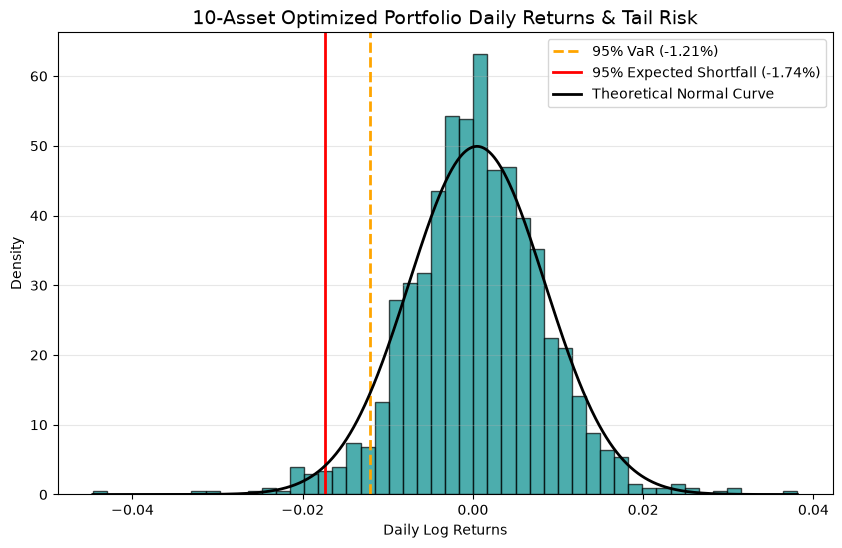

In [179]:
plt.figure(figsize=(10, 6))
plt.hist(port_daily_returns, bins=50, alpha=0.7,density=True ,color='darkcyan', edgecolor='black')

plt.make_this_clean = True
plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'95% VaR ({var_95:.2%})')
plt.axvline(es_95, color='red', linestyle='-', linewidth=2, label=f'95% Expected Shortfall ({es_95:.2%})')


plt.title('10-Asset Optimized Portfolio Daily Returns & Tail Risk', fontsize=14)
plt.xlabel('Daily Log Returns')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)


# Now Fitting the theoritical normal distribution on the data.

from scipy.stats import norm
x = np.linspace(port_daily_returns.min(), port_daily_returns.max(),1000)
y = norm.pdf(x,mean_return,(variance)**0.5)

plt.plot(x, y, color='black', linestyle='-', linewidth=2, label='Theoretical Normal Curve')
plt.legend(loc='upper right')